In [1]:
# 1] Pre-processing

In [28]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
df = pd.read_csv("adult_with_headers (1).csv")

In [29]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df = df.replace('?', np.nan)
print(df.isnull().sum())
missing_percent = df.isnull().mean() * 100
print(missing_percent)

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education_num     0.000000
marital_status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    0.000000
native_country    1.790486
income            0.000000
dtype: float64


In [30]:
cat_cols = df.select_dtypes(include='object').columns
imputer = SimpleImputer(strategy='most_frequent')
imputed_array = imputer.fit_transform(df[cat_cols])
imputed_df = pd.DataFrame(imputed_array, columns=cat_cols, index=df.index)
df[cat_cols] = imputed_df

In [33]:
# a) Standard Scaling
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler_std = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler_std.fit_transform(df[num_cols])

In [34]:
# b) MinMax Scaling
scaler_mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler_mm.fit_transform(df[num_cols])

In [38]:
print("Before Scaling:\n", df[num_cols].describe())
print("\nAfter Standard Scaling:\n", df_standard[num_cols].describe())
print("\nAfter Min-Max Scaling:\n", df_minmax[num_cols].describe())

Before Scaling:
                 age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

After Standard Scaling:
                 age 

In [39]:
# Standard Scaling is used when data follows approximately normal distribution. The reason behind it is many ML algorithms 
# (like Logistic Regression, SVM, Linear Regression) assume data is centered around 0.
# MinMax Scaling is used when using algorithms are based on distance or gradient. The reason behind it is it keeps all features in the same 
# small range, preventing large-value features from dominating.

In [40]:
# 2] Encoding

In [42]:
# a) One Hot Encoding
from sklearn.preprocessing import OneHotEncoder
onehot_cols = [col for col in cat_cols if df[col].nunique() < 5]
print("One-Hot Encoded columns:", onehot_cols)
df_onehot = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

One-Hot Encoded columns: ['sex', 'income']


In [43]:
# b) Label Encoding
from sklearn.preprocessing import LabelEncoder
label_cols = [col for col in cat_cols if df[col].nunique() >= 5]
print("Label Encoded columns:", label_cols)
le = LabelEncoder()
for col in label_cols:
    df_onehot[col] = le.fit_transform(df_onehot[col])

Label Encoded columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [44]:
print("\nData Types After Encoding:\n", df_onehot.dtypes)
print("\nSample Encoded Data:\n", df_onehot.head())


Data Types After Encoding:
 age               int64
workclass         int64
fnlwgt            int64
education         int64
education_num     int64
marital_status    int64
occupation        int64
relationship      int64
race              int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country    int64
sex_Male           bool
income_>50K        bool
dtype: object

Sample Encoded Data:
    age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          9             13               4   
1   50          5   83311          9             13               2   
2   38          3  215646         11              9               0   
3   53          3  234721          1              7               2   
4   28          3  338409          9             13               2   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           0             1     4          2174             0     

In [45]:
# One Hot Encoding :-
# Pros :- 
# 1) No assumption of order
# 2) Works well with ML algorithms.
# Cons :-
# 1) Increases dimensionality.
# 2) Memory heavy.
# Label Encoding :-
# Pros :-
# 1) Compact and simple.
# 2) Works well for tree-based models.
# Cons :-
# 1) Implies false order relationship.
# 2) Can mislead distance-based models.

In [46]:
# 3] Feature Engineering

In [47]:
df['capital_diff'] = df['capital_gain'] - df['capital_loss']
# It helps in making insights that are related to investment. High capital difference indicates more income.

In [48]:
def age_group(x):
    if x < 25:
        return 'Young'
    elif x <= 40:
        return 'Adult'
    elif x <= 60:
        return 'Mid-age'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)
# Conversion of continuous variable into meaningful categorial variables. Income depends upon age hence if we group age into categories then it becomes 
# easy to predict income.

In [57]:
df[num_cols].skew().sort_values(ascending=False)
# checking skewness.

capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64

In [58]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])
# capital_gain column has more skewed value hence to reduce it we use log transformation.

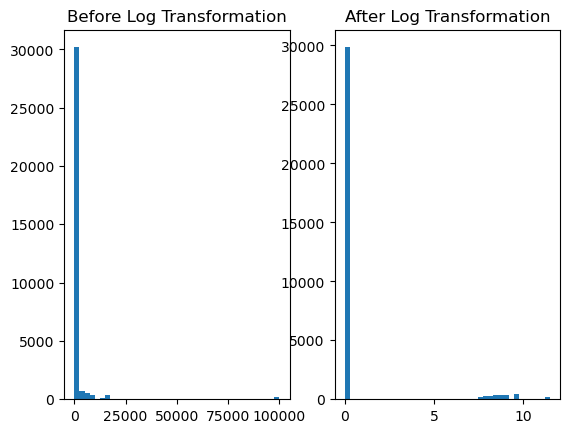

In [56]:
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.hist(df['capital_gain'], bins=40)
plt.title('Before Log Transformation')
plt.subplot(1,2,2)
plt.hist(df['capital_gain_log'], bins=40)
plt.title('After Log Transformation')
plt.show()

In [59]:
# We can see the before case is right skewed. After we apply log transformation the data gets balanced and thus reduces skewness.